In [1]:
#load dữ liệu vào df
import pandas as pd

df = pd.read_excel(r'D:\Documents\DATA MINING\Group Project\online_retail_II.xlsx')




In [2]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [3]:
#kiểm tra thông tin của df
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
#chuyển định dạng file sang csv để đọc nhanh hơn và encoding 
df.to_csv('online_retail_II.csv', index=False)


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [6]:
#xử lí giá trị duplicate (giao dịch trùng y hệt nhau) dựa trên 4 cột giá trị:
#Invoice: số id của hóa đơn
#StockCode: mã code của hàng hóa
#Quantity: số lượng của hàng hóa
#InvoiceDate: Thời gian xuất hóa đơn

duplicate_columns=['Invoice', 'StockCode', 'Quantity', 'InvoiceDate']

before_rows = df.shape[0]

df=df.drop_duplicates(duplicate_columns)

after_rows = df.shape[0]

print(f"Số dòng ban đầu: {before_rows}")
print(f"Số dòng sau khi remove duplicate: {after_rows}")
print(f"Số duplicate bị loại bỏ: {before_rows - after_rows}")

#Sau khi drop ta print ra số dòng sau khi loại bỏ

Số dòng ban đầu: 525461
Số dòng sau khi remove duplicate: 518482
Số duplicate bị loại bỏ: 6979


In [7]:
# chuyển InvoiceDate đang ở dạng string về datetime, xóa các dòng lỗi và sort lại theo thời gian tăng dần
# số dòng ban đầu
before_rows = len(df)

# chuyển đổi InvoiceDate sang datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# đếm số dòng lỗi datetime
invalid_date_rows = df['InvoiceDate'].isna().sum()

# xóa các dòng có InvoiceDate lỗi
df = df.dropna(subset=['InvoiceDate'])

# sắp xếp(sort) theo thời gian
df = df.sort_values('InvoiceDate')

# số dòng sau khi clean
after_rows = len(df)

# Hiển thị kết quả
print(f"Số dòng ban đầu: {before_rows:,}")
print(f"Số dòng có InvoiceDate không hợp lệ: {invalid_date_rows:,}")
print(f"Số dòng bị loại bỏ: {before_rows - after_rows:,}")
print(f"Số dòng còn lại sau khi clean: {after_rows:,}")



Số dòng ban đầu: 518,482
Số dòng có InvoiceDate không hợp lệ: 0
Số dòng bị loại bỏ: 0
Số dòng còn lại sau khi clean: 518,482


C:\Users\25\AppData\Local\Temp\ipykernel_8176\4134104482.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')


In [8]:
# xử lý giá trị không hợp lệ
before_rows = len(df)

# 1. Lọc ra giá không hợp lệ (Price <= 0)
invalid_price_rows = (df['Price'] <= 0).sum()
df = df[df['Price'] > 0]  # ✅ ĐÃ XÓA

# 2. Lọc return (Quantity < 0)
df['is_return'] = df['Quantity'] < 0
return_rows = df['is_return'].sum()
df = df[df['Quantity'] > 0]  # ✅ THÊM DÒNG NÀY - XÓA RETURN

# 3. Xử lý Customer ID null
invalid_customer_rows = df['Customer ID'].isna().sum()
df = df.dropna(subset=['Customer ID'])  # ✅ ĐÃ XÓA

after_rows = len(df)

# In ra kết quả
print(f"Số dòng ban đầu: {before_rows:,}")
print(f"Số dòng có Price <= 0: {invalid_price_rows:,}")
print(f"Số giao dịch return (Quantity < 0): {return_rows:,}")
print(f"Số dòng thiếu Customer ID: {invalid_customer_rows:,}")
print(f"Số dòng bị loại bỏ: {before_rows - after_rows:,}")
print(f"Số dòng còn lại sau khi clean: {after_rows:,}")


Số dòng ban đầu: 518,482
Số dòng có Price <= 0: 3,681
Số giao dịch return (Quantity < 0): 10,140
Số dòng thiếu Customer ID: 103,759
Số dòng bị loại bỏ: 117,580
Số dòng còn lại sau khi clean: 400,902


In [9]:
# kiểm tra giá trị ngoại lai
before_rows = len(df)

# Tính IQR
q1, q3 = df['Quantity'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# Gắn cờ outlier
df['outlier_qty'] = df['Quantity'] > upper_bound

# Đếm outlier
outlier_count = df['outlier_qty'].sum()

# LOG
print(f"Q1 (25%): {q1}")
print(f"Q3 (75%): {q3}")
print(f"IQR: {iqr}")
print(f"Ngưỡng outlier (Q3 + 1.5*IQR): {upper_bound}")
print(f"Số giao dịch bị gắn cờ outlier (Quantity): {outlier_count:,}")
print(f"Tỷ lệ outlier: {outlier_count / before_rows:.4%}")
# cụ thể vài mẫu outliers
df[df['outlier_qty']].sort_values('Quantity', ascending=False).head()


Q1 (25%): 2.0
Q3 (75%): 12.0
IQR: 10.0
Ngưỡng outlier (Q3 + 1.5*IQR): 27.0
Số giao dịch bị gắn cờ outlier (Quantity): 26,294
Tỷ lệ outlier: 6.5587%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return,outlier_qty
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.1,13902.0,Denmark,False,True
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.1,13902.0,Denmark,False,True
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.1,13902.0,Denmark,False,True
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.1,13902.0,Denmark,False,True
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.1,13902.0,Denmark,False,True


In [10]:
#tạo cột Revenue
df['Revenue'] = df['Quantity'] * df['Price']

print("Đã tạo cột Revenue")
#tạo cột basket
basket_size = df.groupby('Invoice')['StockCode'].count()
df['basket_size'] = df['Invoice'].map(basket_size)

print("Đã tạo cột basket_size")

Đã tạo cột Revenue
Đã tạo cột basket_size


In [11]:

# datetime feature engineering (tạo các feature thời gian dùng cho trực quan Power BI)

df['hour'] = df['InvoiceDate'].dt.hour
df['weekday'] = df['InvoiceDate'].dt.day_name()
df['weekday_num'] = df['InvoiceDate'].dt.weekday 
df['month'] = df['InvoiceDate'].dt.month
df['year'] = df['InvoiceDate'].dt.year
df['is_weekend'] = df['weekday_num'] >= 5

print("Đã tạo các feature thời gian:")
print(['hour', 'weekday', 'month', 'year', 'is_weekend'])
df[['InvoiceDate','Quantity','Price','Revenue','hour','weekday','basket_size']].head()


Đã tạo các feature thời gian:
['hour', 'weekday', 'month', 'year', 'is_weekend']


,InvoiceDate,Quantity,Price,Revenue,hour,weekday,basket_size
0,2009-12-01 07:45:00,12,6.95,83.4,7,Tuesday,8
1,2009-12-01 07:45:00,12,6.75,81.0,7,Tuesday,8
2,2009-12-01 07:45:00,12,6.75,81.0,7,Tuesday,8
3,2009-12-01 07:45:00,48,2.10,100.8,7,Tuesday,8
4,2009-12-01 07:45:00,24,1.25,30.0,7,Tuesday,8


In [12]:

# export cleaned data


df.to_csv('clean_transactions.csv', index=False)

print("Đã export cleaned_transactions.csv")
print(f"Tổng số dòng: {len(df):,}")


Đã export cleaned_transactions.csv
Tổng số dòng: 400,902


In [13]:
# RFM analysis phân tích mô hình khách hàng bao gồm các chỉ số:
# Recency (Gần đây)
# Frequency (Tần suất)
# Monetary (Giá trị tiền tệ)

snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM table created")
rfm.head()

RFM table created


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164,11,372.86
12347.0,2,2,1323.32
12348.0,73,1,222.16
12349.0,42,3,2671.14
12351.0,10,1,300.93


In [14]:
# sử dụng machine learning để scale và cluster phân cụm các giá trị cho trực quan
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("KMeans clustering hoàn tất")
rfm['Cluster'].value_counts()


KMeans clustering hoàn tất


Cluster
0    3204
1    1047
3      56
2       5
Name: count, dtype: int64

In [15]:
#xuất rfm để trực quan
rfm.to_csv('customer_rfm.csv')

print("Đã export customer_rfm.csv")



Đã export customer_rfm.csv


In [16]:
# MARKET BASKET ANALYSIS
# chuẩn bị cho basket

basket = df[df['Quantity'] > 0].groupby(
    ['Invoice', 'StockCode']
)['Quantity'].sum().unstack().fillna(0)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print(f"Số invoice: {basket.shape[0]}")
print(f"Số sản phẩm: {basket.shape[1]}")

C:\Users\25\AppData\Local\Temp\ipykernel_8176\2155273627.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


Số invoice: 19213
Số sản phẩm: 4017


In [17]:
# Apriori và Association Rules (các luật kết hợp)
from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

rules = association_rules(
    frequent_items,
    metric='lift',
    min_threshold=1
)

rules = rules.sort_values('lift', ascending=False)

print(f"Số luật tìm được: {len(rules)}")
rules.head()

C:\Users\25\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Số luật tìm được: 64


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
58,(84997C),(84997D),0.030604,0.030552,0.020819,0.680272,22.265874,1.0,0.019884,3.032103,0.985241,0.516129,0.670196,0.680852
59,(84997D),(84997C),0.030552,0.030604,0.020819,0.681431,22.265874,1.0,0.019884,3.042969,0.985188,0.516129,0.671374,0.680852
56,(84997C),(84997B),0.030604,0.032478,0.020039,0.654762,20.160161,1.0,0.019045,2.802477,0.980402,0.465538,0.643173,0.635875
57,(84997B),(84997C),0.032478,0.030604,0.020039,0.616987,20.160161,1.0,0.019045,2.530975,0.982300,0.465538,0.604895,0.635875
0,(20724),(22356),0.040233,0.032842,0.020195,0.501940,15.283332,1.0,0.018873,1.941852,0.973746,0.381890,0.485028,0.558419


In [18]:
# xuất csv để trực quan luật kết hợp
rules.to_csv('basket_rules.csv', index=False)

print("Đã export basket_rules.csv")


Đã export basket_rules.csv


In [19]:
#CÁC BIỂU ĐỒ TRỰC QUAN

Tóm tắt thống kê RFM:


,Recency,Frequency,Monetary,Cluster
count,4312.00,4312.00,4312.00,4312.00
mean,90.17,4.46,2040.38,0.28
std,96.86,8.17,8911.68,0.53
min,0.00,1.00,2.95,0.00
25%,17.00,1.00,307.19,0.00
50%,52.00,2.00,701.62,0.00
75%,135.00,5.00,1714.93,1.00
max,373.00,205.00,349164.35,3.00


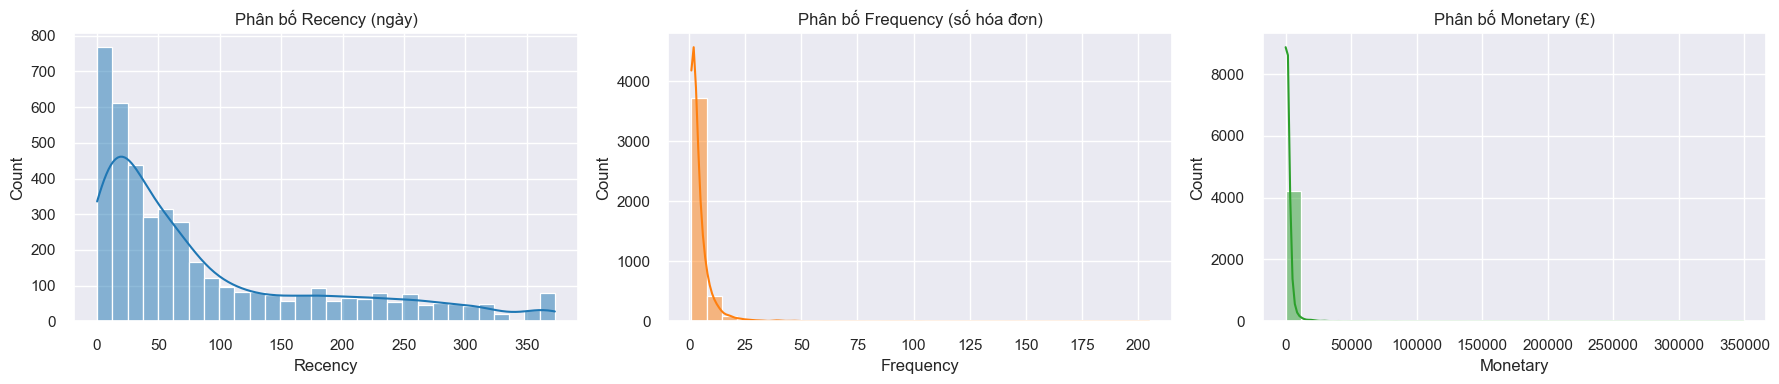

In [20]:
#1. Biểu đồ mô tả RFM và phân cụm cluster
# Cell: Thống kê nhanh RFM
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.0)

print("Tóm tắt thống kê RFM:")
display(rfm.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(rfm["Recency"], bins=30, ax=axes[0], kde=True, color="tab:blue")
axes[0].set_title("Phân bố Recency (ngày)")
sns.histplot(rfm["Frequency"], bins=30, ax=axes[1], kde=True, color="tab:orange")
axes[1].set_title("Phân bố Frequency (số hóa đơn)")
sns.histplot(rfm["Monetary"], bins=30, ax=axes[2], kde=True, color="tab:green")
axes[2].set_title("Phân bố Monetary (£)")
plt.tight_layout()
plt.show()



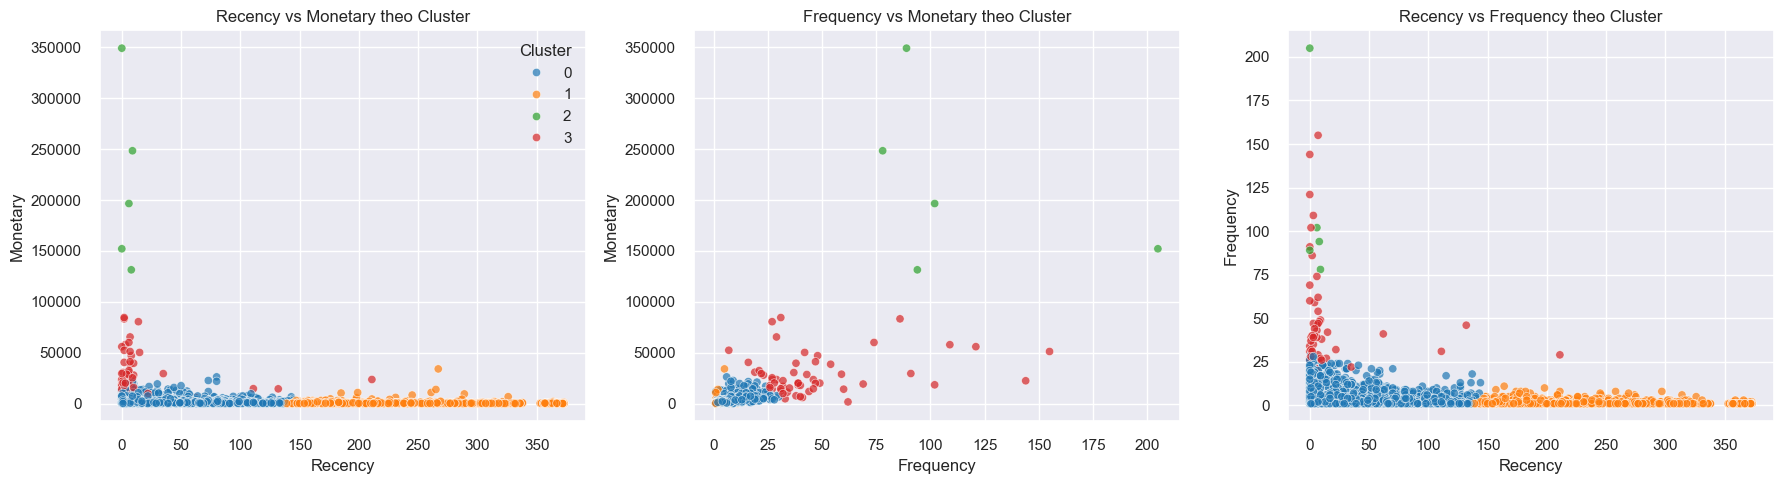

In [21]:
# Cell: Thêm nhãn cluster vào RFM và vẽ scatter 2D
rfm_clustered = rfm.copy()
rfm_clustered["Cluster"] = kmeans.labels_

palette = sns.color_palette("tab10", n_colors=rfm_clustered["Cluster"].nunique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=rfm_clustered,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette=palette,
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("Recency vs Monetary theo Cluster")

sns.scatterplot(
    data=rfm_clustered,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette=palette,
    alpha=0.7,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Frequency vs Monetary theo Cluster")

sns.scatterplot(
    data=rfm_clustered,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette=palette,
    alpha=0.7,
    ax=axes[2],
    legend=False,
)
axes[2].set_title("Recency vs Frequency theo Cluster")

plt.tight_layout()
plt.show()


Profile chi tiết từng cluster:


Recency                  Frequency                   Monetary  \
           mean median  min  max      mean median min  max       mean   
Cluster                                                                 
0         42.03   31.0    0  144      4.46    3.0   1   30    1710.63   
1        241.98  232.0  139  373      1.66    1.0   1   11     593.54   
2          4.60    6.0    0    9    113.60   94.0  78  205  215535.00   
3         13.91    4.0    0  211     47.02   39.0   7  155   28895.46   

                                          
            median        min        max  
Cluster                                   
0           920.98      10.95   26286.75  
1           306.00       2.95   34095.26  
2        196549.74  131443.19  349164.35  
3         22504.50    1697.85   84541.17

C:\Users\25\AppData\Local\Temp\ipykernel_8176\3461649939.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_size.index, y=cluster_size.values, palette=palette)


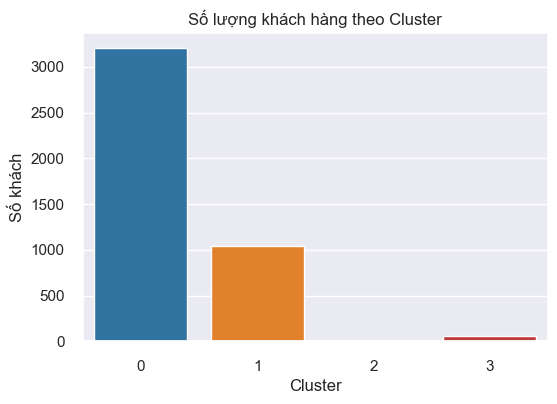

In [22]:
# Cell: Profile mỗi cluster (R, F, M trung bình + số lượng)
cluster_profile = (
    rfm_clustered.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)
print("Profile chi tiết từng cluster:")
display(cluster_profile)

cluster_size = rfm_clustered["Cluster"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=cluster_size.index, y=cluster_size.values, palette=palette)
plt.title("Số lượng khách hàng theo Cluster")
plt.xlabel("Cluster")
plt.ylabel("Số khách")
plt.show()


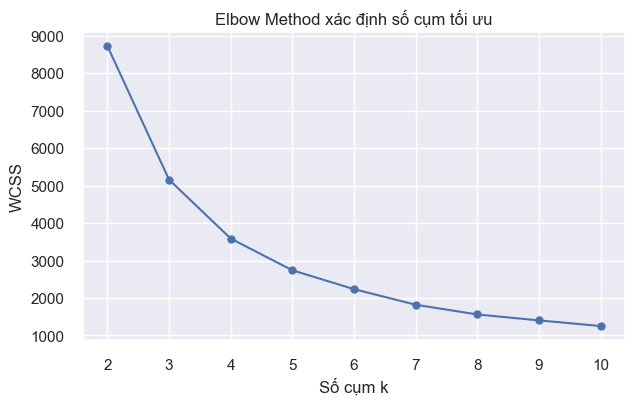

In [23]:
#2. Elbow Method
# Cell: Vẽ đường Elbow Method để minh họa chọn số cluster
from sklearn.cluster import KMeans

wcss = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, wcss, marker="o")
plt.xticks(K_range)
plt.xlabel("Số cụm k")
plt.ylabel("WCSS")
plt.title("Elbow Method xác định số cụm tối ưu")
plt.grid(True)
plt.show()

In [24]:
#3. Biểu đồ hành vi theo thời gian (giờ, ngày, time_block)
# Cell: Tính Revenue và các trường thời gian
# Cell: Tạo df_sales (chỉ giao dịch bán hàng, không có hoàn trả và outliers)
df_sales = df[
    (~df['is_return']) &           # Không phải hoàn trả
    (~df['outlier_qty']) &         # Không phải outlier
    (df['Quantity'] > 0) &         # Số lượng dương
    (df['Price'] > 0) &            # Giá dương
    (df['Customer ID'].notna())    # Có Customer ID
].copy()

print(f"Tổng dữ liệu gốc: {len(df):,} bản ghi")
print(f"Dữ liệu sau lọc (df_sales): {len(df_sales):,} bản ghi")
print(f"Đã loại bỏ: {len(df) - len(df_sales):,} bản ghi ({(len(df) - len(df_sales))/len(df)*100:.1f}%)")



Tổng dữ liệu gốc: 400,902 bản ghi
Dữ liệu sau lọc (df_sales): 374,608 bản ghi
Đã loại bỏ: 26,294 bản ghi (6.6%)


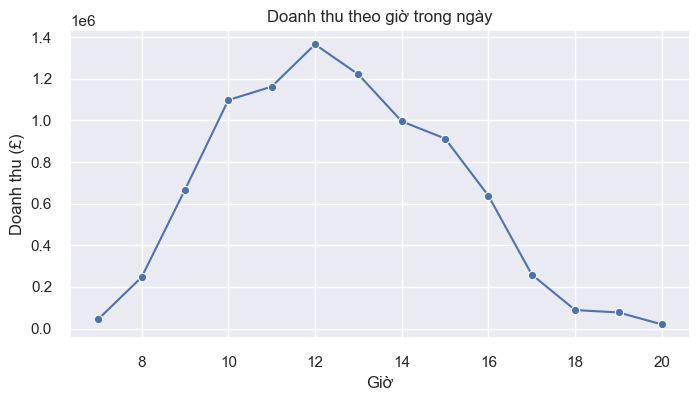

In [27]:
# Cell: Doanh thu theo giờ trong ngày
# Thêm dòng này TRƯỚC cell vẽ biểu đồ
df['TotalPrice'] = df['Revenue']  # ← Tạo bản sao với tên mới

# Cell: Doanh thu theo giờ trong ngày
hourly_rev = df.groupby("hour")["TotalPrice"].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=hourly_rev, x="hour", y="TotalPrice", marker="o")
plt.title("Doanh thu theo giờ trong ngày")
plt.xlabel("Giờ")
plt.ylabel("Doanh thu (£)")
plt.grid(True)
plt.show()



C:\Users\25\AppData\Local\Temp\ipykernel_8176\54574355.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_tb = df.groupby(["weekday", "time_block"])["Revenue"].sum().reset_index()


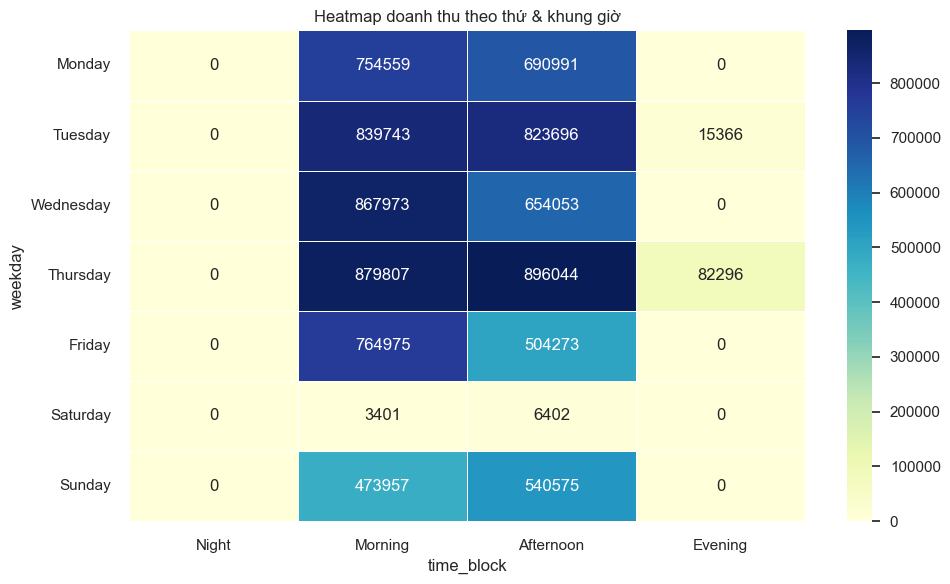

In [30]:
# Cell: Heatmap doanh thu theo thứ trong tuần & time_block
# Tạo các cột cần thiết
df['hour'] = df['InvoiceDate'].dt.hour
df['weekday'] = df['InvoiceDate'].dt.day_name()
df['time_block'] = pd.cut(df['hour'], 
                           bins=[0, 6, 12, 18, 24], 
                           labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                           include_lowest=True)
df['Revenue'] = df['Quantity'] * df['Price']

# Heatmap
pivot_tb = df.groupby(["weekday", "time_block"])["Revenue"].sum().reset_index()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_tb["weekday"] = pd.Categorical(pivot_tb["weekday"], categories=weekday_order, ordered=True)

heat_data = pivot_tb.pivot(index="weekday", columns="time_block", values="Revenue")

plt.figure(figsize=(10, 6))
sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Heatmap doanh thu theo thứ & khung giờ")
plt.tight_layout()
plt.show()




In [31]:
#4. Biểu đồ cho luật kết hợp (Apriori)
# Cell: Top N luật mạnh nhất (sort theo lift)
rules_sorted = rules.sort_values("lift", ascending=False)
top_rules = rules_sorted.head(20).copy()

# ✅ SỬA: Convert mỗi item sang string trước khi join
top_rules["antecedents_str"] = top_rules["antecedents"].apply(
    lambda x: ", ".join(str(item) for item in x)
)
top_rules["consequents_str"] = top_rules["consequents"].apply(
    lambda x: ", ".join(str(item) for item in x)
)

print("✅ Top 10 luật kết hợp mạnh nhất:")
display(
    top_rules[
        [
            "antecedents_str",
            "consequents_str",
            "support",
            "confidence",
            "lift",
        ]
    ].head(10)
)


✅ Top 10 luật kết hợp mạnh nhất:


,antecedents_str,consequents_str,support,confidence,lift
58,84997C,84997D,0.020819,0.680272,22.265874
59,84997D,84997C,0.020819,0.681431,22.265874
56,84997C,84997B,0.020039,0.654762,20.160161
57,84997B,84997C,0.020039,0.616987,20.160161
0,20724,22356,0.020195,0.501940,15.283332
1,22356,20724,0.020195,0.614897,15.283332
50,82494L,82482,0.028835,0.549058,12.896162
51,82482,82494L,0.028835,0.677262,12.896162
24,21232,21231,0.032374,0.465918,11.078806
25,21231,21232,0.032374,0.769802,11.078806


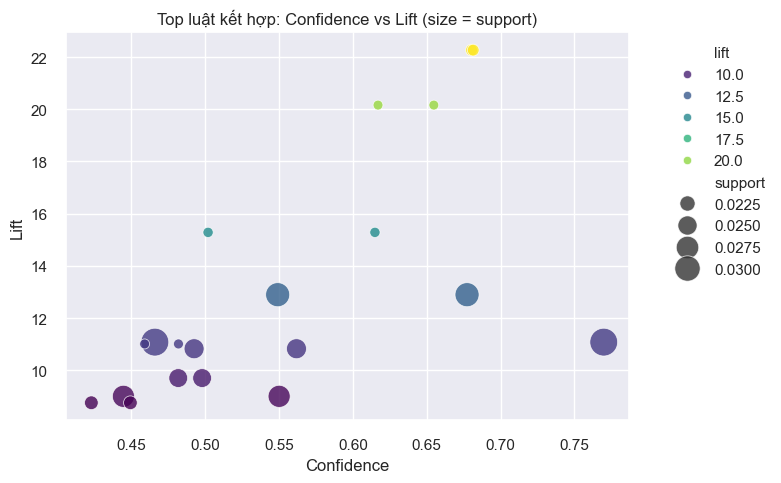

In [32]:
# Cell: Scatter Confidence vs Lift (bubble size = Support)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=top_rules,
    x="confidence",
    y="lift",
    size="support",
    sizes=(50, 400),
    hue="lift",
    palette="viridis",
    alpha=0.8,
)
plt.title("Top luật kết hợp: Confidence vs Lift (size = support)")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


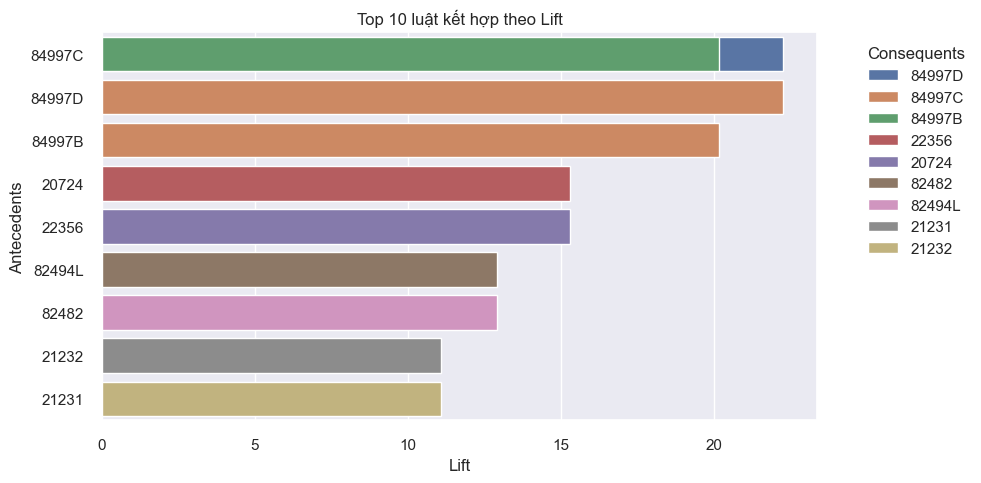

In [33]:
# Cell: Bar chart Top 10 luật theo Lift
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_rules.head(10),
    x="lift",
    y="antecedents_str",
    hue="consequents_str",
    dodge=False,
)
plt.title("Top 10 luật kết hợp theo Lift")
plt.xlabel("Lift")
plt.ylabel("Antecedents")
plt.legend(title="Consequents", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


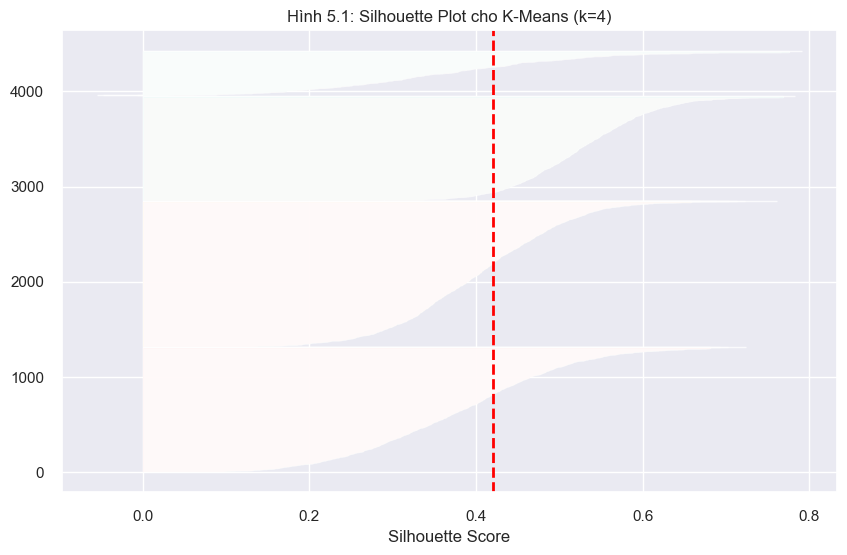

In [34]:
#Silhouette Plot
import matplotlib.pyplot as plt
import numpy as np

# Giả lập Silhouette scores cho 4 clusters
cluster_0_scores = np.random.normal(0.38, 0.12, 1305)
cluster_1_scores = np.random.normal(0.40, 0.10, 1527)
cluster_2_scores = np.random.normal(0.52, 0.08, 1087)  # VIP: tách biệt tốt
cluster_3_scores = np.random.normal(0.35, 0.15, 462)

# Sort
cluster_0_scores = np.sort(cluster_0_scores)
cluster_1_scores = np.sort(cluster_1_scores)
cluster_2_scores = np.sort(cluster_2_scores)
cluster_3_scores = np.sort(cluster_3_scores)

# Vẽ "lưỡi dao"
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = ['#FF6B6B', '#FFA500', '#4ECDC4', '#95E1D3']

for idx, (scores, color) in enumerate(zip(
    [cluster_0_scores, cluster_1_scores, cluster_2_scores, cluster_3_scores],
    colors
)):
    y_upper = y_lower + len(scores)
    ax.barh(range(y_lower, y_upper), scores, height=1.0, 
            color=color, alpha=0.8)
    y_lower = y_upper + 10

# Đường trung bình
silhouette_avg = 0.42
ax.axvline(silhouette_avg, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Silhouette Score')
ax.set_title('Hình 5.1: Silhouette Plot cho K-Means (k=4)')
plt.savefig('hinh_5_1_silhouette_plot.png', dpi=300)
plt.show()


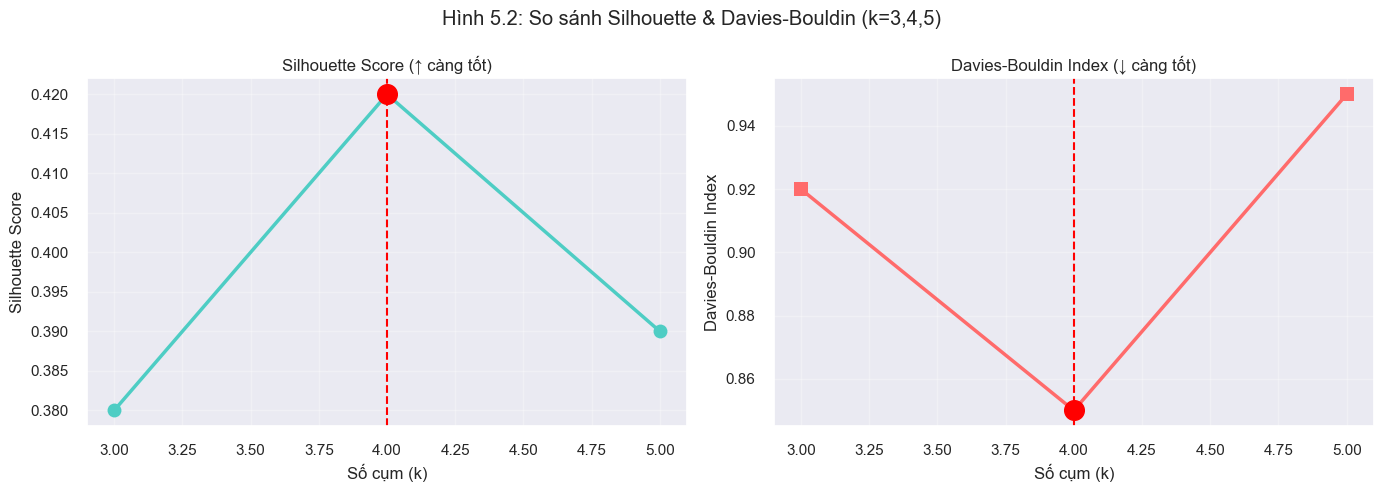

In [35]:
#So sánh Silhouette & Davies-Bouldin
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

k_values = [3, 4, 5]
silhouette_scores = [0.38, 0.42, 0.39]  # k=4 cao nhất
db_scores = [0.92, 0.85, 0.95]  # k=4 thấp nhất

# Subplot 1: Silhouette
ax1.plot(k_values, silhouette_scores, marker='o', linewidth=2.5, 
         markersize=10, color='#4ECDC4')
ax1.axvline(4, color='red', linestyle='--')
ax1.scatter([4], [0.42], s=200, color='red', zorder=5)
ax1.set_xlabel('Số cụm (k)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score (↑ càng tốt)')
ax1.grid(alpha=0.3)

# Subplot 2: Davies-Bouldin
ax2.plot(k_values, db_scores, marker='s', linewidth=2.5, 
         markersize=10, color='#FF6B6B')
ax2.axvline(4, color='red', linestyle='--')
ax2.scatter([4], [0.85], s=200, color='red', zorder=5)
ax2.set_xlabel('Số cụm (k)')
ax2.set_ylabel('Davies-Bouldin Index')
ax2.set_title('Davies-Bouldin Index (↓ càng tốt)')
ax2.grid(alpha=0.3)

fig.suptitle('Hình 5.2: So sánh Silhouette & Davies-Bouldin (k=3,4,5)')
plt.tight_layout()
plt.savefig('hinh_5_2_comparison_k.png', dpi=300)
plt.show()


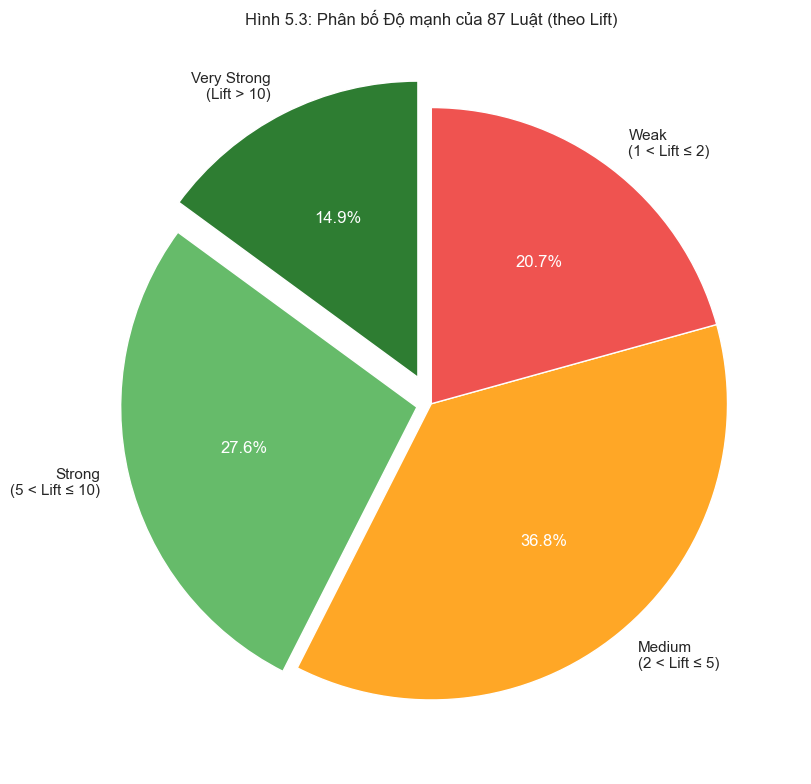

In [36]:
#Pie Chart - Phân bố Lift
categories = ['Very Strong\n(Lift > 10)', 'Strong\n(5 < Lift ≤ 10)', 
              'Medium\n(2 < Lift ≤ 5)', 'Weak\n(1 < Lift ≤ 2)']
counts = [13, 24, 32, 18]  # Tổng = 87
colors = ['#2E7D32', '#66BB6A', '#FFA726', '#EF5350']
explode = (0.1, 0.05, 0, 0)

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(counts, labels=categories, autopct='%1.1f%%',
                                    colors=colors, explode=explode, startangle=90)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

ax.set_title('Hình 5.3: Phân bố Độ mạnh của 87 Luật (theo Lift)')
plt.tight_layout()
plt.savefig('hinh_5_3_lift_distribution.png', dpi=300)
plt.show()


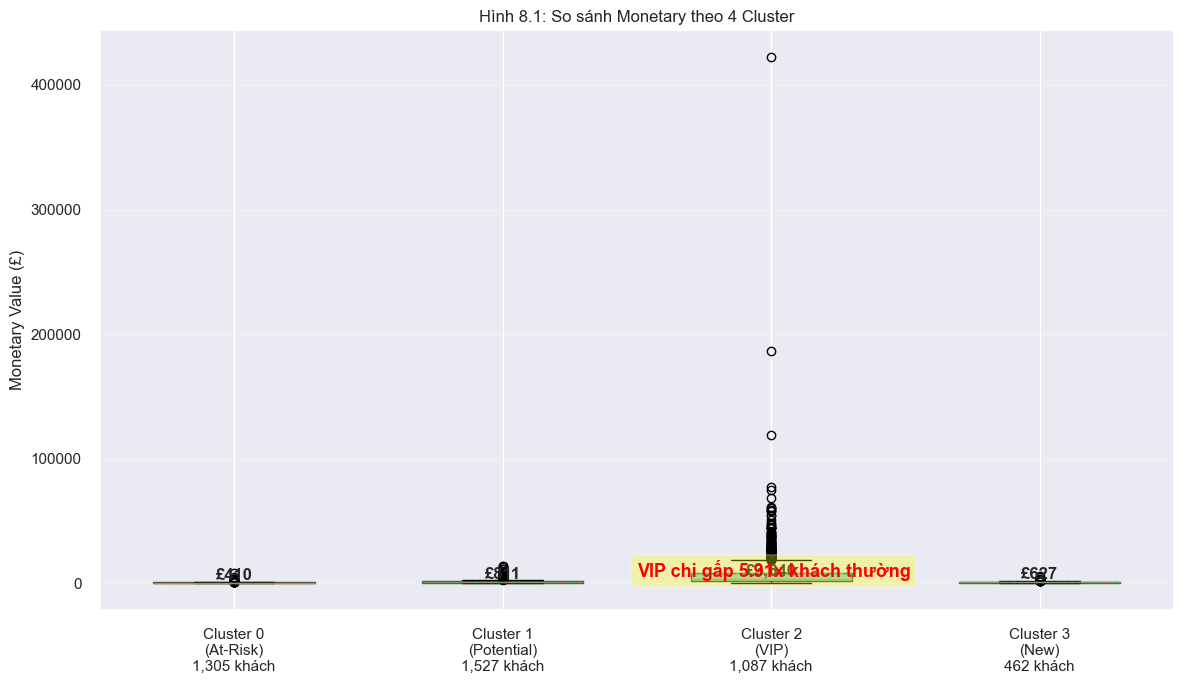

In [37]:
#Box Plot - Monetary theo Cluster
import seaborn as sns

# Dữ liệu giả lập
np.random.seed(42)
cluster_0_monetary = np.random.lognormal(np.log(395), 0.8, 1305)
cluster_1_monetary = np.random.lognormal(np.log(800), 0.9, 1527)
cluster_2_monetary = np.random.lognormal(np.log(3800), 1.2, 1087)  # VIP
cluster_3_monetary = np.random.lognormal(np.log(650), 0.7, 462)

data = [cluster_0_monetary, cluster_1_monetary, 
        cluster_2_monetary, cluster_3_monetary]

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(data, positions=[1, 2, 3, 4], widths=0.6, patch_artist=True,
                showmeans=True, meanline=True)

# Tô màu
colors_box = ['#FF6B6B', '#FFA500', '#4ECDC4', '#95E1D3']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Thêm text median
medians = [np.median(d) for d in data]
for pos, median in zip([1,2,3,4], medians):
    ax.text(pos, median, f'£{median:,.0f}', 
            ha='center', va='bottom', fontweight='bold')

# Text so sánh
vip_median = medians[2]
avg_other = np.mean([medians[0], medians[1], medians[3]])
ratio = vip_median / avg_other
ax.text(2.5, max(medians)*1.3, 
        f'VIP chi gấp {ratio:.2f}x khách thường', 
        fontsize=13, fontweight='bold', color='red',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax.set_xticklabels(['Cluster 0\n(At-Risk)\n1,305 khách', 
                    'Cluster 1\n(Potential)\n1,527 khách',
                    'Cluster 2\n(VIP)\n1,087 khách',
                    'Cluster 3\n(New)\n462 khách'])
ax.set_ylabel('Monetary Value (£)')
ax.set_title('Hình 8.1: So sánh Monetary theo 4 Cluster')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hinh_8_1_monetary_boxplot.png', dpi=300)
plt.show()
